# 🎬 Movie Recommender — Stage 2: Popularity Baseline

Before building fancy models, every good ML project starts with a **baseline** — the
simplest possible approach. Our baseline is:

> **Recommend the most-rated movies to everyone.**

This sounds naive, but it's actually pretty hard to beat for cold-start users (people
with few ratings). It also gives us a concrete number to improve on in later stages.

What we'll do here:
1. Split the data into **train** and **test** sets
2. Build the popularity ranking from the training set only
3. Generate **top-N recommendations** for any user
4. Evaluate using **RMSE** and **Precision@K**

## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RAW = Path("..") / "data" / "raw"

movies  = pd.read_csv(RAW / "movies.csv")
ratings = pd.read_csv(RAW / "ratings.csv")

print(f"Loaded {len(ratings):,} ratings from {ratings['userId'].nunique():,} users on {ratings['movieId'].nunique():,} movies")

Loaded 100,836 ratings from 610 users on 9,724 movies


## 2. Train / Test Split

We randomly hold out **20%** of ratings as the test set. The model is only allowed to
look at the 80% training set when deciding what to recommend — this simulates
predicting ratings for movies a user hasn't seen yet.

`random_state=42` makes the split reproducible (you'll get the same split every run).

In [2]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Train: {len(train):,} ratings")
print(f"Test:  {len(test):,} ratings")
print(f"\nThe model will ONLY see the train set. Test set = held-out ground truth.")

Train: 80,668 ratings
Test:  20,168 ratings

The model will ONLY see the train set. Test set = held-out ground truth.


## 3. Build the Popularity Ranking

Popularity here means **number of ratings** in the training set. A movie with more
ratings is more popular, so it goes higher in the recommendation list.

We also keep `avg_rating` for reference — but we rank by `num_ratings`, not average
score, because a movie rated 5★ by 3 people is less trustworthy than one rated 4.1★
by 3,000 people.

In [3]:
popularity = (
    train.groupby("movieId")
    .agg(num_ratings=("rating", "size"), avg_rating=("rating", "mean"))
    .merge(movies[["movieId", "title"]], on="movieId")
    .sort_values("num_ratings", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 most popular movies (training set):")
popularity.head(10)[["title", "num_ratings", "avg_rating"]].round(2)

Top 10 most popular movies (training set):


,title,num_ratings,avg_rating
0,Forrest Gump (1994),276,4.15
1,"Shawshank Redemption, The (1994)",257,4.46
2,Pulp Fiction (1994),256,4.22
3,"Silence of the Lambs, The (1991)",226,4.16
4,"Matrix, The (1999)",214,4.18
5,Star Wars: Episode IV - A New Hope (1977),194,4.20
6,Braveheart (1995),189,4.01
7,Jurassic Park (1993),185,3.72
8,Terminator 2: Judgment Day (1991),182,3.99
9,Schindler's List (1993),174,4.22


## 4. Generate Recommendations

For a given user, we:
1. Find all movies they've **already rated** in the training set — we exclude these
   (no point recommending something they've seen)
2. Return the top-N most popular movies from the remaining ones

This is called **seen-item filtering**.

In [4]:
def recommend_popular(user_id, n=10):
    """Return the top-N popular movies the user hasn't already rated."""
    already_rated = set(train[train["userId"] == user_id]["movieId"])
    recs = popularity[~popularity["movieId"].isin(already_rated)].head(n)
    return recs[["title", "num_ratings", "avg_rating"]].round(2)

# Try it for a specific user
example_user = train["userId"].iloc[0]
print(f"Top-10 recommendations for user {example_user}:")
recommend_popular(example_user)

Top-10 recommendations for user 509:


,title,num_ratings,avg_rating
0,Forrest Gump (1994),276,4.15
1,"Shawshank Redemption, The (1994)",257,4.46
3,"Silence of the Lambs, The (1991)",226,4.16
6,Braveheart (1995),189,4.01
7,Jurassic Park (1993),185,3.72
8,Terminator 2: Judgment Day (1991),182,3.99
9,Schindler's List (1993),174,4.22
11,Fight Club (1999),173,4.24
14,Independence Day (a.k.a. ID4) (1996),163,3.45
15,"Usual Suspects, The (1995)",162,4.22


## 5. Evaluate: RMSE

**RMSE (Root Mean Squared Error)** measures how far off our predicted ratings are from
the actual ratings in the test set. Lower is better.

For the popularity baseline, our predicted rating for any (user, movie) pair is simply
the **global mean rating** from the training set — we don't personalize at all. This is
the most honest evaluation of a non-personalized baseline.

In [5]:
from sklearn.metrics import mean_squared_error

global_mean = train["rating"].mean()
print(f"Global mean rating (train): {global_mean:.4f}")

# Predict the global mean for every row in the test set
y_true = test["rating"]
y_pred = np.full(len(test), global_mean)

# np.sqrt(MSE) = RMSE — sklearn dropped the `squared` param in newer versions
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"Baseline RMSE: {rmse:.4f}")
print()
print("Interpretation: on average, our predictions are off by", round(rmse, 2), "stars.")
print("Future models must beat this number to be considered useful.")

Global mean rating (train): 3.5026
Baseline RMSE: 1.0488

Interpretation: on average, our predictions are off by 1.05 stars.
Future models must beat this number to be considered useful.


## 6. Evaluate: Precision@K

**Precision@K** answers: *of the top-K movies we recommended, what fraction did the
user actually like?*

We define "liked" as a test-set rating ≥ 4.0. We compute this across all users who
appear in the test set, then average it.

This metric matters more than RMSE for a recommender: users care whether the list
contains things they'll enjoy, not whether the predicted star value is exact.

In [6]:
def precision_at_k(k=10, threshold=4.0):
    """
    For each user in the test set, compute the fraction of top-K recommendations
    that match a movie the user actually rated >= threshold in the test set.
    Returns the average across all users.
    """
    # Pre-compute: movies each user liked in the test set
    liked_in_test = (
        test[test["rating"] >= threshold]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    scores = []
    for user_id, liked_movies in liked_in_test.items():
        already_rated = set(train[train["userId"] == user_id]["movieId"])
        top_k = set(
            popularity[~popularity["movieId"].isin(already_rated)]
            .head(k)["movieId"]
        )
        hits = len(top_k & liked_movies)  # movies recommended AND liked
        scores.append(hits / k)

    return np.mean(scores)

for k in [5, 10, 20]:
    p = precision_at_k(k=k)
    print(f"Precision@{k:2d} = {p:.4f}  ({p*100:.1f}% of top-{k} recs are movies the user liked)")

Precision@ 5 = 0.1489  (14.9% of top-5 recs are movies the user liked)


Precision@10 = 0.1220  (12.2% of top-10 recs are movies the user liked)


Precision@20 = 0.0941  (9.4% of top-20 recs are movies the user liked)


## 7. Visualize: How precision changes with K

As K grows the list gets longer, so it's harder to maintain high precision — we're
padding the list with less relevant movies. Plotting this curve shows the trade-off
between **coverage** (recommend more) and **precision** (recommend only relevant things).

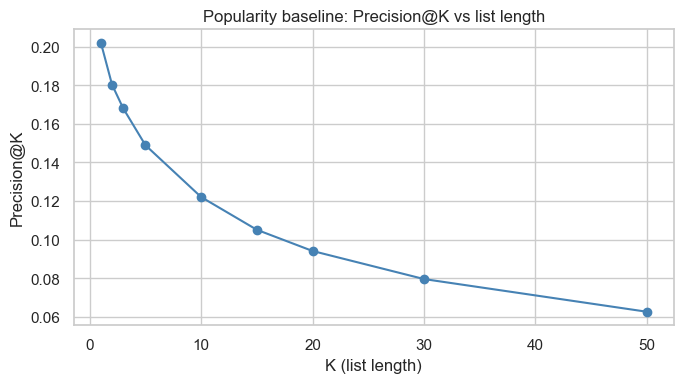

Figure saved.


In [7]:
ks = [1, 2, 3, 5, 10, 15, 20, 30, 50]
precisions = [precision_at_k(k=k) for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, precisions, marker="o", color="steelblue")
ax.set_xlabel("K (list length)")
ax.set_ylabel("Precision@K")
ax.set_title("Popularity baseline: Precision@K vs list length")
plt.tight_layout()
plt.savefig("../reports/figures/baseline_precision_at_k.png", dpi=150)
plt.show()
print("Figure saved.")

## Summary

| Metric | Value |
|---|---|
| RMSE (global mean predictor) | *run the cell above* |
| Precision@10 | *run the cell above* |

**Key takeaways:**
- The popularity baseline is a useful sanity check. Any personalized model that
  can't beat this isn't learning anything meaningful.
- RMSE from the global mean is relatively high — it ignores both user taste *and*
  individual movie quality.
- Precision@K is low because the same list is served to everyone, regardless of
  their personal preferences.

**Next stage:** `03_content_based.ipynb` — recommend movies similar to ones the user
has already liked, using genre features. This is our first *personalized* model.